In [26]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier

Part 1 — Problem Definition & Dataset Verification

In [2]:
# Task # 01

df = pd.read_csv("Dataset/clean_churn.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Dataset shape: ", df.shape)

Dataset shape:  (7021, 20)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7021 entries, 0 to 7020
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   object 
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   object 
 3   Dependents        7021 non-null   object 
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   object 
 6   MultipleLines     7021 non-null   object 
 7   InternetService   7021 non-null   object 
 8   OnlineSecurity    7021 non-null   object 
 9   OnlineBackup      7021 non-null   object 
 10  DeviceProtection  7021 non-null   object 
 11  TechSupport       7021 non-null   object 
 12  StreamingTV       7021 non-null   object 
 13  StreamingMovies   7021 non-null   object 
 14  Contract          7021 non-null   object 
 15  PaperlessBilling  7021 non-null   object 
 16  PaymentMethod     7021 non-null   object 


In [5]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [6]:
# Task # 02

comparison_baseline = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        0.7872,
        0.7986
    ],
    "Precision": [
        0.5978,
        0.6202
    ],
    "Recall": [
        0.4602,
        0.5057
    ],
    "F1-Score": [
        0.5201,
        0.5571
    ]
})

display(comparison_baseline)

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.7872,0.5978,0.4602,0.5201
1,Tuned Random Forest,0.7986,0.6202,0.5057,0.5571


Part 2 — Feature Scaling & Preparation

In [7]:
# Task # 03

X = df.drop("Churn", axis=1)
y = df["Churn"]

y = y.map({
    "Yes": 1,
    "No": 0
})

X = pd.get_dummies(X, drop_first=True)

In [8]:
print("Remaining categorical columns:")
print(X.select_dtypes(include = "object").columns)

print("\nX shape:", X.shape) 
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Remaining categorical columns:
Index([], dtype='object')

X shape: (7021, 30)
y shape: (7021,)

Target distribution:
Churn
0    5164
1    1857
Name: count, dtype: int64


In [11]:
# Task # 05

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (5616, 30)
Testing Features: (1405, 30)
Training Target: (5616,)
Testing Target: (1405,)


In [12]:
scaler = StandardScaler()

In [13]:
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\nScaled Training Features:", X_train_scaled.shape)
print("Scaled Testing Features:", X_test_scaled.shape)


Scaled Training Features: (5616, 30)
Scaled Testing Features: (1405, 30)


Part 3 — Logistic Regression

In [17]:
# Task # 06 --- Logistic Regression

log_reg = LogisticRegression()

In [18]:
log_reg.fit(X_train_scaled, y_train)

y_pred_logreg = log_reg.predict(X_test_scaled)

print("First 20 predictions:")
print(y_pred_logreg[:20])

First 20 predictions:
[1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1]


In [20]:
# Task # 07 --- Evaluate Logistic Regression

accuracy = accuracy_score(y_test, y_pred_logreg)
precision = precision_score(y_test, y_pred_logreg)
recall = recall_score(y_test, y_pred_logreg)
f1 = f1_score(y_test, y_pred_logreg)

In [22]:
print("Logistic Regression Results")
print(f"Accuracy :  {accuracy:.4f}")
print(f"Precision:  {precision:.4f}")
print(f"Recall   :  {recall:.4f}")
print(f"F1-Score :  {f1:.4f}")


cm = confusion_matrix(y_test, y_pred_logreg)

print("\nConfusion Matrix:")
print(cm)

Logistic Regression Results
Accuracy :  0.7936
Precision:  0.5969
Recall   :  0.5426
F1-Score :  0.5685

Confusion Matrix:
[[924 129]
 [161 191]]


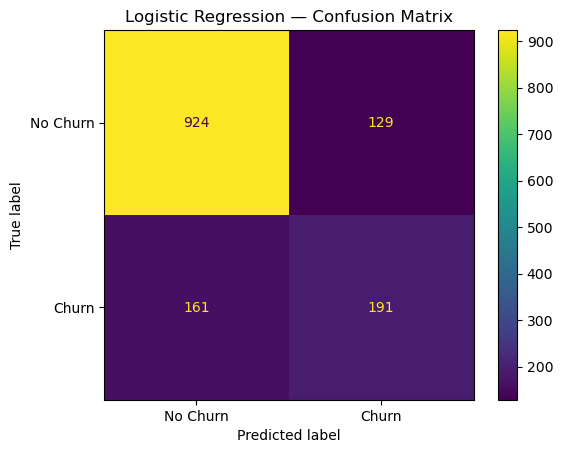

In [23]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Logistic Regression — Confusion Matrix")
plt.show()

In [24]:
# Task # 08 --- Predict Probabilities

y_prob_logreg = log_reg.predict_proba(X_test_scaled)

print("Predicted probabilities:")
print(y_prob_logreg[:5])


Predicted probabilities:
[[0.37124487 0.62875513]
 [0.72631814 0.27368186]
 [0.92887526 0.07112474]
 [0.99584147 0.00415853]
 [0.59416632 0.40583368]]


In [25]:
print("\nDetailed results:")

for i in range(5):
    print(
        f"Customer {i+1}: "
        f"No Churn = {y_prob_logreg[i][0]:.4f}, "
        f"Churn = {y_prob_logreg[i][1]:.4f}, "
        f"Prediction = {y_pred_logreg[i]}"
    )


Detailed results:
Customer 1: No Churn = 0.3712, Churn = 0.6288, Prediction = 1
Customer 2: No Churn = 0.7263, Churn = 0.2737, Prediction = 0
Customer 3: No Churn = 0.9289, Churn = 0.0711, Prediction = 0
Customer 4: No Churn = 0.9958, Churn = 0.0042, Prediction = 0
Customer 5: No Churn = 0.5942, Churn = 0.4058, Prediction = 0


Part 4 — KNN & Choosing K

In [27]:
# Task # 09 --- KNN - Testing different values of k

k_values = [1, 3, 5, 7, 9, 11, 15, 21]

knn_results = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors = k)

    knn.fit(X_train_scaled, y_train)

    y_pred_knn = knn.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred_knn)
    f1 = f1_score(y_test, y_pred_knn)

    knn_results.append({
        "K": k,
        "Accuracy": accuracy,
        "F1-Score": f1
    })

knn_results_df = pd.DataFrame(knn_results)

display(knn_results_df)

,K,Accuracy,F1-Score
0,1,0.727402,0.500652
1,3,0.753737,0.522099
2,5,0.748043,0.502809
3,7,0.765125,0.533898
4,9,0.770107,0.544429
5,11,0.766548,0.538028
6,15,0.775801,0.554455
7,21,0.782206,0.576177


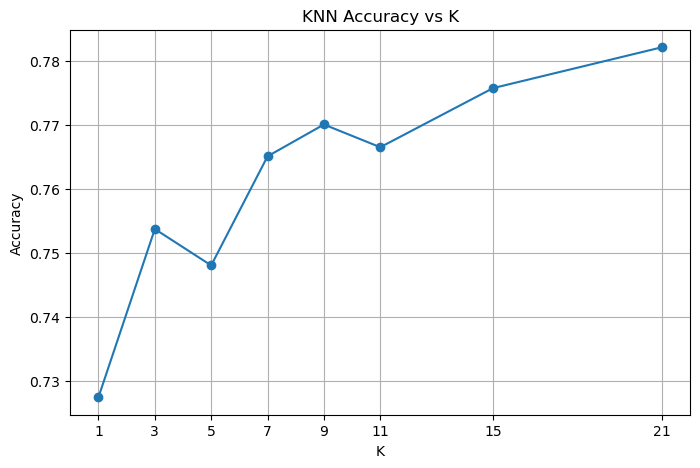

In [28]:
# Task # 10 --- KNN accuracy vs k

plt.figure(figsize=(8, 5))

plt.plot(
    knn_results_df["K"],
    knn_results_df["Accuracy"],
    marker="o"
)

plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")
plt.xticks(knn_results_df["K"])
plt.grid(True)

plt.show()

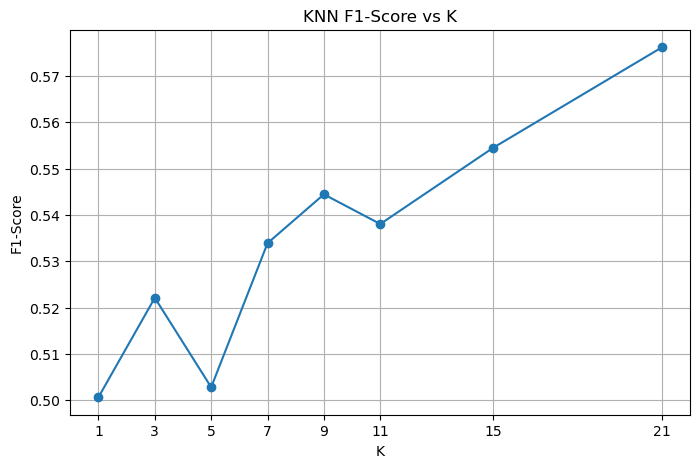

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    knn_results_df["K"],
    knn_results_df["F1-Score"],
    marker="o"
)

plt.xlabel("K")
plt.ylabel("F1-Score")
plt.title("KNN F1-Score vs K")
plt.xticks(knn_results_df["K"])
plt.grid(True)

plt.show()

In [30]:
best_k_accuracy = knn_results_df.loc[
    knn_results_df["Accuracy"].idxmax(), "K"
]

best_k_f1 = knn_results_df.loc[
    knn_results_df["F1-Score"].idxmax(), "K"
]

print("Best K based on Accuracy:", best_k_accuracy)
print("Best K based on F1-Score:", best_k_f1)

Best K based on Accuracy: 21
Best K based on F1-Score: 21


In [31]:
# Task # 11 --- Final KNN Model - k = 21

best_k = 21

knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)

y_pred_knn_final = knn_final.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, y_pred_knn_final)
knn_precision = precision_score(y_test, y_pred_knn_final)
knn_recall = recall_score(y_test, y_pred_knn_final)
knn_f1 = f1_score(y_test, y_pred_knn_final)

print("Final KNN Results (K = 21)")
print(f"Accuracy :  {knn_accuracy:.4f}")
print(f"Precision:  {knn_precision:.4f}")
print(f"Recall   :  {knn_recall:.4f}")
print(f"F1-Score :  {knn_f1:.4f}")

cm_knn = confusion_matrix(y_test, y_pred_knn_final)

print("\nConfusion Matrix:")
print(cm_knn)

Final KNN Results (K = 21)
Accuracy :  0.7822
Precision:  0.5622
Recall   :  0.5909
F1-Score :  0.5762

Confusion Matrix:
[[891 162]
 [144 208]]


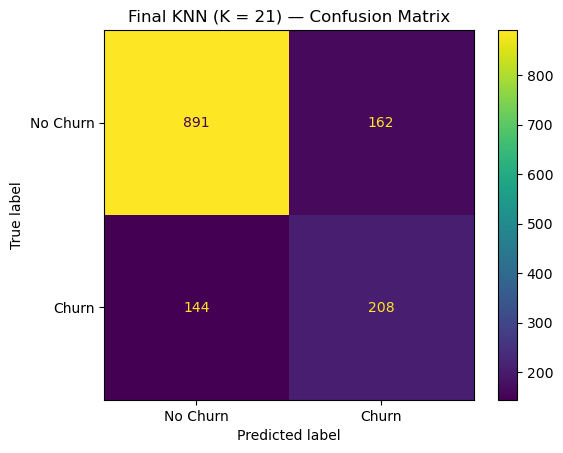

In [32]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Final KNN (K = 21) — Confusion Matrix")
plt.show()

Part 5 — Model Comparison (4 Models)

In [33]:
# Task # 12 --- Four Comparison Table

comparison_df = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Tuned Random Forest",
        "Logistic Regression",
        "KNN (K=21)"
    ],
    "Accuracy": [
        0.7872,
        0.7986,
        accuracy,
        knn_accuracy
    ],
    "Precision": [
        0.5978,
        0.6202,
        precision,
        knn_precision
    ],
    "Recall": [
        0.4602,
        0.5057,
        recall,
        knn_recall
    ],
    "F1-Score": [
        0.5201,
        0.5571,
        f1,
        knn_f1
    ]
})

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.787200,0.597800,0.460200,0.520100
1,Tuned Random Forest,0.798600,0.620200,0.505700,0.557100
2,Logistic Regression,0.782206,0.596875,0.542614,0.576177
3,KNN (K=21),0.782206,0.562162,0.590909,0.576177


In [34]:
comparison_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.7872,0.5978,0.4602,0.5201
1,Tuned Random Forest,0.7986,0.6202,0.5057,0.5571
2,Logistic Regression,0.7822,0.5969,0.5426,0.5762
3,KNN (K=21),0.7822,0.5622,0.5909,0.5762


Part 6 — Coefficient Interpretation

In [35]:
# Task # 14 --- Logistic Regression Coefficients & Odds Ratios

coefficients = log_reg.coef_[0]

feature_names = X.columns

odds_ratios = np.exp(coefficients)

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Odds Ratio": odds_ratios
})


coef_df["Absolute Coefficient"] = coef_df["Coefficient"].abs()

coef_sorted = coef_df.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

display(
    coef_sorted[
        ["Feature", "Coefficient", "Odds Ratio"]
    ].head(10).round(4)
)

,Feature,Coefficient,Odds Ratio
1,tenure,-1.3826,0.2509
3,TotalCharges,0.6622,1.9391
25,Contract_Two year,-0.5570,0.5729
10,InternetService_Fiber optic,0.5386,1.7137
2,MonthlyCharges,-0.4813,0.6179
24,Contract_One year,-0.2543,0.7755
23,StreamingMovies_Yes,0.2127,1.2370
21,StreamingTV_Yes,0.1836,1.2016
19,TechSupport_Yes,-0.1733,0.8409
9,MultipleLines_Yes,0.1731,1.1889


In [36]:
# Interpretation of 4 Selected Features

selected_features = [
    "tenure",
    "TotalCharges",
    "Contract_Two year",
    "InternetService_Fiber optic"
]

interpretation_df = coef_df[
    coef_df["Feature"].isin(selected_features)
][["Feature", "Coefficient", "Odds Ratio"]].copy()

interpretation_df["Interpretation"] = [
    "A one-standard-deviation increase in tenure is associated with approximately 0.251 times the odds of churn, holding other features constant.",
    
    "A one-standard-deviation increase in TotalCharges is associated with approximately 1.94 times the odds of churn, holding other features constant.",
    
    "Customers with a two-year contract have approximately 0.573 times the odds of churn compared with the reference contract category, holding other features constant.",
    
    "Customers with Fiber optic Internet service have approximately 1.71 times the odds of churn compared with the reference Internet Service category, holding other features constant."
]

display(interpretation_df.round(4))

,Feature,Coefficient,Odds Ratio,Interpretation
1,tenure,-1.3826,0.2509,A one-standard-deviation increase in tenure is...
3,TotalCharges,0.6622,1.9391,A one-standard-deviation increase in TotalChar...
10,InternetService_Fiber optic,0.5386,1.7137,Customers with a two-year contract have approx...
25,Contract_Two year,-0.5570,0.5729,Customers with Fiber optic Internet service ha...


Part 7 — Final Model Selection & Conclusion